In [1]:
%pip install shap lime

     ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
     ---- ----------------------------------- 0.3/2.5 MB ? eta -:--:--
     ---------------------------------------- 2.5/2.5 MB 12.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/2.8 MB 

In [2]:
# # SHAP and LIME Explanation Example
#
# This notebook demonstrates how to use SHAP and LIME to explain the predictions of a machine learning model. We'll use the Red Wine Quality dataset.

# ## 1. Import Libraries and Load Data

import pandas as pd
import numpy as np
import sklearn
import sklearn.ensemble
from sklearn.model_selection import train_test_split
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

c:\Users\rushi\miniconda3\envs\test\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [0]:
# Load the dataset (Assuming the file is in the same directory or accessible path)
# You might need to download it first, e.g., from Kaggle:
# https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
try:
    df = pd.read_csv('./winequality-red.csv', sep=',') # Adjust separator if needed
except FileNotFoundError:
    print("Error: 'winequality-red.csv' not found. Please download the dataset and place it in the correct directory.")
    # As a fallback, using a sample dataset from shap if wine quality is unavailable
    print("Using SHAP's sample California housing data as a fallback.")
    X_full, y_full = shap.datasets.california(display=False)
    # Convert to DataFrame for consistency
    feature_names = [f"feature_{i}" for i in range(X_full.shape[1])] # Create generic feature names
    df = pd.DataFrame(X_full, columns=feature_names)
    df['target'] = y_full # Use 'target' as the name for the dependent variable

In [0]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [0]:
# Define features (X) and target (y)
# If using wine dataset:
if 'quality' in df.columns:
    X = df.drop('quality', axis=1)
    y = df['quality']
    target_name = 'quality'
    feature_names = X.columns.tolist()
    class_names = sorted(y.unique().astype(str)) # For LIME classification (treating quality as discrete)
    mode = 'regression' # SHAP/LIME mode
# If using fallback housing dataset:
elif 'target' in df.columns:
    X = df.drop('target', axis=1)
    y = df['target']
    target_name = 'target'
    feature_names = X.columns.tolist()
    class_names = None # Not applicable for regression target
    mode = 'regression' # SHAP/LIME mode
else:
     raise ValueError("Could not identify target column ('quality' or 'target') in the DataFrame.")


In [0]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Loaded and Split:")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Feature names: {feature_names}")

Data Loaded and Split:
Training data shape: (1279, 11)
Testing data shape: (320, 11)
Feature names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [0]:

# ## 2. Train a Model
# We'll train a simple Random Forest model. SHAP and LIME are model-agnostic, so you could use other models like XGBoost, SVM, or Neural Networks.

In [0]:

# Train a RandomForest model
model = sklearn.ensemble.RandomForestRegressor(n_estimators=100, random_state=42) # Use Regressor for wine quality/housing
model.fit(X_train, y_train)

print("Model Trained: RandomForestRegressor")
# Evaluate (optional)
print(f"Test R^2 Score: {model.score(X_test, y_test):.4f}")

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Model Trained: RandomForestRegressor
Test R^2 Score: 0.5390


In [0]:

# ## 3. Explain using SHAP
# SHAP explains predictions by calculating the contribution of each feature to the prediction compared to the average prediction (base value).

In [0]:
# Initialize JavaScript visualization in the notebook
shap.initjs()

# Create a SHAP explainer object
# For tree-based models like RandomForest, TreeExplainer is efficient
explainer_shap = shap.TreeExplainer(model)

SHAP values calculated.
Displaying SHAP Summary Plot (Beeswarm):


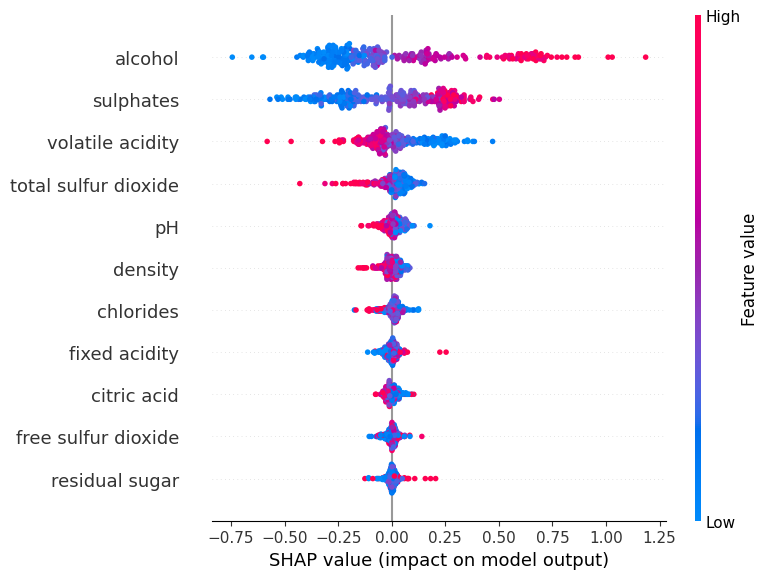

In [0]:
# Calculate SHAP values for the test set
shap_values = explainer_shap.shap_values(X_test)

print("SHAP values calculated.")


# ### SHAP Summary Plot
# Shows the global importance and impact of each feature.

print("Displaying SHAP Summary Plot (Beeswarm):")
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

In [0]:

# ### SHAP Force Plot (Single Prediction)
# Explains a single prediction, showing features pushing the prediction higher (red) or lower (blue) than the base value.

# Explain the first prediction in the test set
instance_index = 0
print(f"\nDisplaying SHAP Force Plot for test instance {instance_index}:")
shap.force_plot(explainer_shap.expected_value, shap_values[instance_index,:], X_test.iloc[instance_index,:], feature_names=feature_names)


Displaying SHAP Force Plot for test instance 0:


In [0]:

# ## 4. Explain using LIME
# LIME explains individual predictions by approximating the complex model locally with a simpler, interpretable model (like linear regression).

# Create a LIME Tabular Explainer
# For regression: mode='regression'
# For classification: mode='classification', class_names needed
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=[target_name] if mode == 'regression' else class_names, # Use target name for regression
    mode=mode
)

In [0]:
print("LIME Explainer created.")

# ### LIME Explanation (Single Prediction)
# Explain the same prediction as with SHAP.

instance_index = 0
instance = X_test.iloc[instance_index]
predict_fn = model.predict # LIME needs a function that takes numpy array and returns predictions

print(f"\nGenerating LIME explanation for test instance {instance_index}:")
explanation_lime = explainer_lime.explain_instance(
    data_row=instance.values,
    predict_fn=predict_fn,
    num_features=len(feature_names) # Show all features
)

In [0]:
# Show the explanation in the notebook
print(f"LIME Explanation for Instance {instance_index} (Prediction: {predict_fn(instance.values.reshape(1, -1))[0]:.2f}):")
explanation_lime.show_in_notebook(show_table=True)


# ## 5. Conclusion
#
# Both SHAP and LIME provide valuable insights into model predictions.
# * **SHAP** gives mathematically grounded Shapley values, providing consistent global and local explanations. `TreeExplainer` is very efficient for tree models.
# * **LIME** focuses on local fidelity, approximating the model around a specific instance. It's truly model-agnostic but can sometimes be less stable than SHAP.
#
# Using both can give a more comprehensive understanding of your model's behavior.